> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 03 决策树：递归划分、节点纯度与树模型

从“如何选择一次划分”开始，逐步推导分类树与回归树，并用 NumPy 和 sklearn 完成可复现实现。

## 模型简介与学习参考

决策树是一类以规则为核心的监督学习模型：它反复选择特征和阈值，把样本递归地划入更纯或误差更小的子区域，最终由叶节点给出类别或连续值。

| 项目 | 内容 |
|---|---|
| 模型定位 | 可解释的非线性监督学习模型 |
| 核心思想 | 用局部最优划分递归构造树结构 |
| 典型任务 | 分类、回归、规则提取与特征重要性分析 |
| 主要优点 | 规则直观；无需特征缩放；能表达非线性关系 |
| 主要限制 | 深树容易过拟合；对数据扰动较敏感；轴对齐划分可能较生硬 |

**学习参考**

- 周志华《机器学习》（西瓜书）第 4 章：决策树。
- [南瓜书（Datawhale）](https://github.com/datawhalechina/pumpkin-book)：补充西瓜书中的公式推导。
- [scikit-learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)：官方模型、参数与剪枝说明。
- [ML-From-Scratch](https://github.com/eriklindernoren/ML-From-Scratch)：参考从零实现的组织方式。

本章在这些资料的基础上重新组织为“原理推导 → 手写实现 → sklearn 调用与案例”，代码与文字均按本教程的教学顺序整合。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 递归划分](#recursive-split)
  - [1.2 信息熵与信息增益](#impurity)
  - [1.3 基尼指数](#gini)
  - [1.4 连续特征阈值](#threshold)
  - [1.5 ID3、C4.5 与 CART](#tree-family)
  - [1.6 停止生长与剪枝](#pruning)
  - [1.7 回归树](#regression-tree)
- [2. NumPy 手写决策树](#scratch)
  - [2.1 图形复现](#figure-code)
  - [2.2 数据准备](#scratch-data)
  - [2.3 模型实现](#scratch-model)
  - [2.4 训练评估](#scratch-evaluation)
  - [2.5 复杂度控制](#depth-experiment)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 Iris 分类调用](#sklearn-basic)
  - [3.2 乳腺癌分类案例](#real-case)
  - [3.3 糖尿病回归案例](#regression-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="recursive-split"></a>
### 1.1 递归划分：从单次判断到树结构

给定训练集

$$
D=\{(\boldsymbol x_i,y_i)\}_{i=1}^{n},\qquad y_i\in\{1,\ldots,K\},
$$

决策树在每个内部节点选择一个问题，例如
\(x_j\le t\)。满足条件的样本进入左子树，其余样本进入右子树：

$$
D_L=\{(\boldsymbol x_i,y_i):x_{ij}\le t\},\qquad
D_R=D\setminus D_L.
$$

随后在左右子集继续提出问题。于是，训练一棵树的关键变成：

> 在当前节点中，应当选择哪个特征 \(j\) 和阈值 \(t\)，才能让划分后的类别更纯？

设当前节点中第 \(k\) 类样本的比例为

$$
p_k=\frac{n_k}{n}.
$$

如果某个 \(p_k=1\)，节点完全纯净；如果各类别比例接近，节点比较混杂。

<a id="impurity"></a>
### 1.2 纯度度量：信息熵与信息增益

信息熵衡量类别分布的不确定性：

$$
H(D)=-\sum_{k=1}^{K}p_k\log_2p_k,
$$

其中约定 \(0\log_2 0=0\)。纯节点熵为 0；二分类中两类各占一半时熵最大，为 1。

一次划分后的不确定性，要按左右子节点的样本比例加权：

$$
H(D\mid j,t)=
\frac{|D_L|}{|D|}H(D_L)
+\frac{|D_R|}{|D|}H(D_R).
$$

划分前后的熵之差就是**信息增益**：

$$
\operatorname{Gain}(D,j,t)
=H(D)-H(D\mid j,t).
$$

信息增益越大，说明这个问题消除的不确定性越多。

**小例子。** 父节点有 10 个样本，其中 6 个正类、4 个负类；某次划分得到
纯净的左节点 \([4,0]\) 和右节点 \([2,4]\)。父节点熵约为 0.971，
加权子节点熵约为 0.551，因此信息增益约为 0.420。

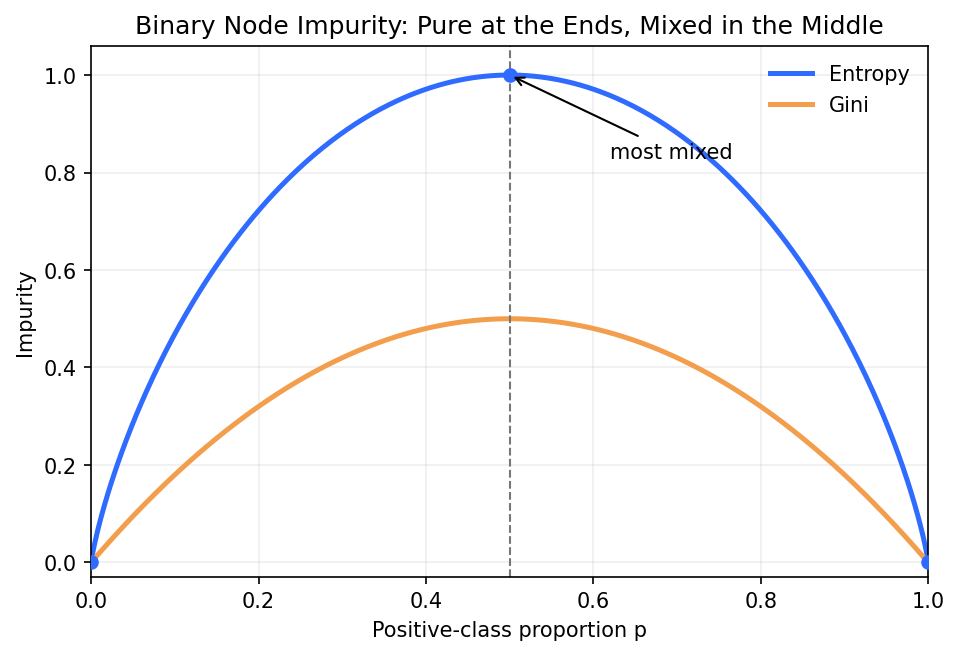

<a id="gini"></a>
### 1.3 分类准则：基尼指数与 CART

基尼指数可以理解为：按照当前类别比例随机给样本贴标签时，贴错标签的概率。

$$
\operatorname{Gini}(D)
=1-\sum_{k=1}^{K}p_k^2
=\sum_{k=1}^{K}p_k(1-p_k).
$$

对候选划分 \((j,t)\)，计算加权子节点不纯度：

$$
G_{\text{split}}(j,t)=
\frac{|D_L|}{|D|}\operatorname{Gini}(D_L)
+\frac{|D_R|}{|D|}\operatorname{Gini}(D_R).
$$

CART 选择使 \(G_{\text{split}}\) 最小、等价地使基尼下降量最大的划分：

$$
\Delta G=\operatorname{Gini}(D)-G_{\text{split}}(j,t).
$$

熵和基尼指数都在衡量“混杂程度”。二者通常给出相近的树；基尼指数不需要计算对数，
因而常作为 CART 分类树的默认选择。本章手写实现使用基尼指数。

<a id="threshold"></a>
### 1.4 阈值搜索：连续特征的最佳切分

对连续特征 \(x_j\)，先将当前节点中的不同取值排序：

$$
v_1<v_2<\cdots<v_m.
$$

类别组成只有在越过某个样本取值时才可能变化，所以只需要检查相邻取值的中点：

$$
t_r=\frac{v_r+v_{r+1}}{2},\qquad r=1,\ldots,m-1.
$$

对每个特征、每个候选阈值计算加权不纯度，选出全局最佳划分。随后对左右子节点重复这个过程，
这就是递归建树。

叶节点不再划分时，分类结果取该节点的多数类：

$$
\hat y=\arg\max_k n_k,
$$

类别概率则取节点内的类别频率：

$$
P(y=k\mid \boldsymbol x)=\frac{n_k}{n}.
$$

<a id="tree-family"></a>
### 1.5 算法对比：ID3、C4.5 与 CART

| 算法 | 典型划分准则 | 树的形式 | 主要特点 |
|---|---|---|---|
| ID3 | 信息增益 | 多叉树 | 容易偏向取值较多的特征 |
| C4.5 | 信息增益率 | 多叉树 | 修正取值数量偏好，可处理连续特征 |
| CART | 分类用基尼，回归用平方误差 | 二叉树 | 同时支持分类与回归；sklearn 采用这种风格 |

<a id="pruning"></a>
### 1.6 复杂度控制：停止生长与剪枝

如果一直划分到每个叶节点只剩极少样本，训练误差会很低，但树可能记住噪声。
常见控制方法有两类：

- **预剪枝**：通过 `max_depth`、`min_samples_split`、`min_samples_leaf` 等条件提前停止；
- **后剪枝**：先长出较大树，再删除收益不足的子树。

CART 的代价复杂度剪枝可写成：

$$
R_\alpha(T)=R(T)+\alpha|T|,
$$

其中 \(R(T)\) 表示拟合误差，\(|T|\) 表示叶节点数量，\(\alpha\) 控制“准确”与“简单”的权衡。

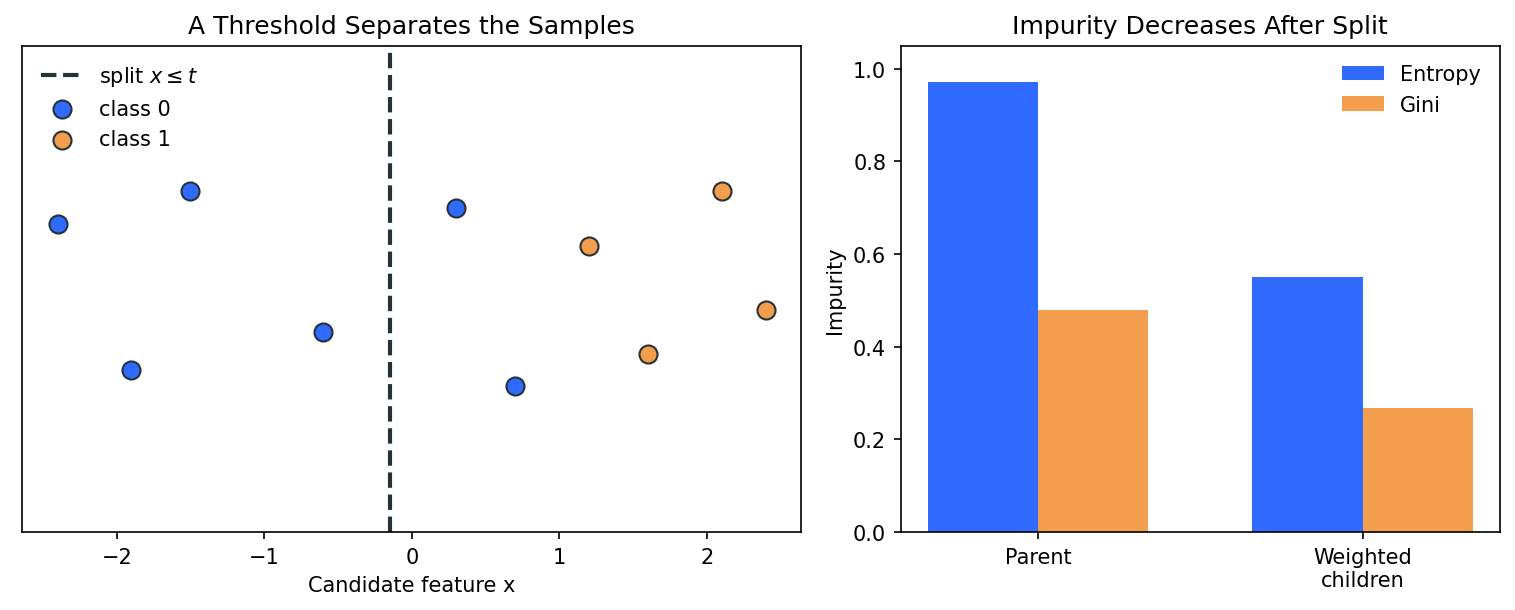

<a id="regression-tree"></a>
### 1.7 回归扩展：平方误差与叶节点均值

回归树预测连续值。若叶节点区域 (R) 输出常数 (c)，平方误差为

$$
E(c)=\sum_{i:\boldsymbol x_i\in R}(y_i-c)^2.
$$

令导数为零：

$$
\frac{\partial E}{\partial c}=-2\sum_{i:\boldsymbol x_i\in R}(y_i-c)=0
\quad\Longrightarrow\quad
c=\frac1{|R|}\sum_{i:\boldsymbol x_i\in R}y_i=\bar y_R.
$$

因此回归树寻找让左右区域平方误差之和最小的阈值，并在叶节点输出目标均值。

#### 图解：递归划分与树结构的一一对应

每个内部节点产生一条平行于坐标轴的边界；沿树从根到叶的判断路径，正好对应二维空间中的一个矩形区域。

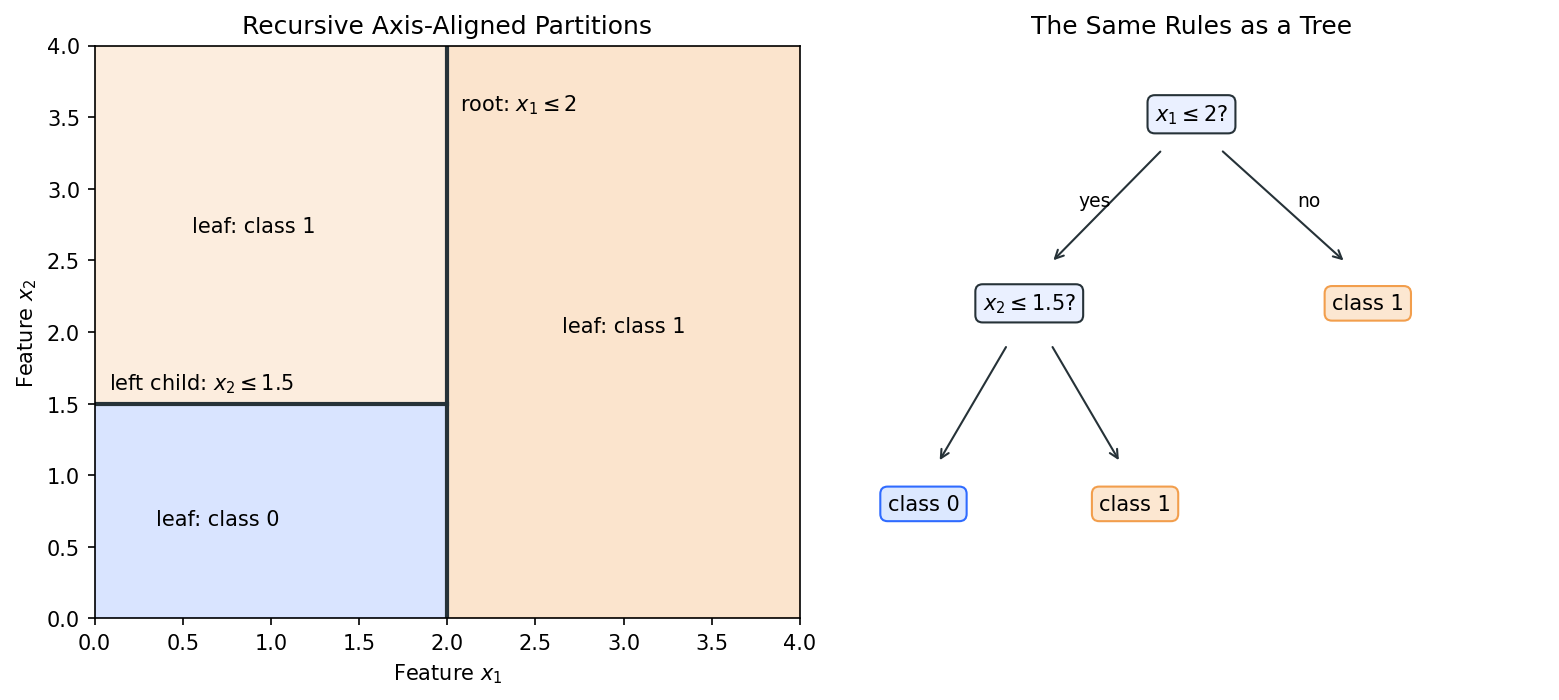

<a id="scratch"></a>
## 2. NumPy 手写决策树

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

以下三段代码复现原理部分的三张图。

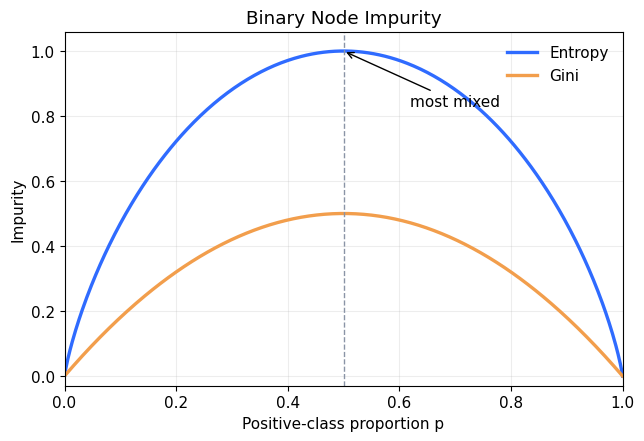

In [1]:
# 复现图 1：熵与基尼曲线
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

BLUE = "#2F6BFF"
ORANGE = "#F29E4C"
OLIVE = "#708238"
DARK = "#263238"
GREY = "#8A94A6"
LIGHT_BLUE = "#EAF0FF"

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.22, "font.size": 11})

def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    probabilities = counts[counts > 0] / counts.sum()
    return -np.sum(probabilities * np.log2(probabilities))

def gini_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    probabilities = counts / counts.sum()
    return 1.0 - np.sum(probabilities ** 2)

positive_ratio = np.linspace(0, 1, 501)
safe_ratio = np.clip(positive_ratio, 1e-12, 1 - 1e-12)
entropy_curve = -(safe_ratio * np.log2(safe_ratio)
                  + (1 - safe_ratio) * np.log2(1 - safe_ratio))
gini_curve = 2 * positive_ratio * (1 - positive_ratio)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(positive_ratio, entropy_curve, color=BLUE, linewidth=2.4, label="Entropy")
ax.plot(positive_ratio, gini_curve, color=ORANGE, linewidth=2.4, label="Gini")
ax.axvline(0.5, color=GREY, linestyle="--", linewidth=1)
ax.annotate("most mixed", xy=(0.5, 1), xytext=(0.62, 0.83),
            arrowprops={"arrowstyle": "->"})
ax.set(xlabel="Positive-class proportion p", ylabel="Impurity",
       title="Binary Node Impurity", xlim=(0, 1), ylim=(-0.03, 1.06))
ax.legend(frameon=False)
plt.show()

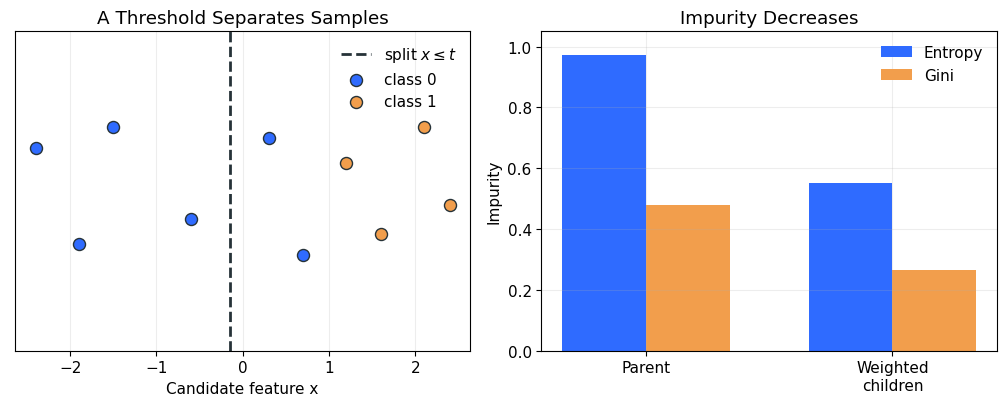

In [2]:
# 复现图 2：划分前后对比
parent_counts = np.array([6, 4])
left_counts = np.array([4, 0])
right_counts = np.array([2, 4])
parent_entropy = entropy_from_counts(parent_counts)
child_entropy = (left_counts.sum() / 10 * entropy_from_counts(left_counts)
                 + right_counts.sum() / 10 * entropy_from_counts(right_counts))
parent_gini = gini_from_counts(parent_counts)
child_gini = (left_counts.sum() / 10 * gini_from_counts(left_counts)
              + right_counts.sum() / 10 * gini_from_counts(right_counts))

x_values = np.array([-2.4, -1.9, -1.5, -0.6, 0.3, 0.7, 1.2, 1.6, 2.1, 2.4])
labels = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])
y_jitter = np.array([0.12, -0.15, 0.18, -0.08, 0.15, -0.18, 0.08, -0.12, 0.18, -0.04])
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
for label, color in [(0, BLUE), (1, ORANGE)]:
    mask = labels == label
    axes[0].scatter(x_values[mask], y_jitter[mask], s=75, color=color,
                    edgecolor=DARK, label=f"class {label}")
axes[0].axvline(-0.15, color=DARK, linestyle="--", linewidth=2, label=r"split $x\leq t$")
axes[0].set(xlabel="Candidate feature x", yticks=[], ylim=(-0.45, 0.45),
            title="A Threshold Separates Samples")
axes[0].legend(frameon=False)
positions = np.arange(2)
width = 0.34
axes[1].bar(positions - width / 2, [parent_entropy, child_entropy], width,
            color=BLUE, label="Entropy")
axes[1].bar(positions + width / 2, [parent_gini, child_gini], width,
            color=ORANGE, label="Gini")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(["Parent", "Weighted\nchildren"])
axes[1].set(ylabel="Impurity", title="Impurity Decreases", ylim=(0, 1.05))
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

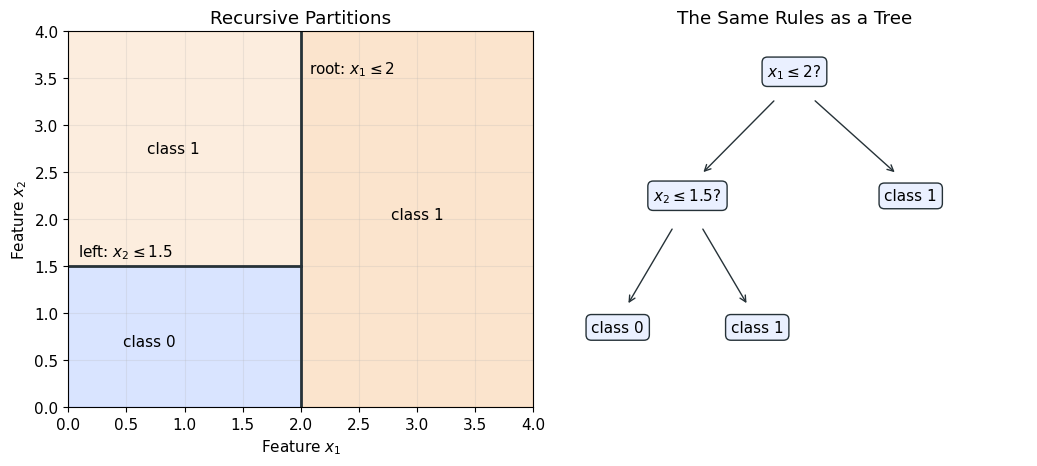

In [3]:
# 复现图 3：递归划分与树结构
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
axes[0].axvspan(0, 2, ymin=0, ymax=0.375, color=BLUE, alpha=0.18)
axes[0].axvspan(0, 2, ymin=0.375, ymax=1, color=ORANGE, alpha=0.18)
axes[0].axvspan(2, 4, color=ORANGE, alpha=0.28)
axes[0].axvline(2, color=DARK, linewidth=2)
axes[0].plot([0, 2], [1.5, 1.5], color=DARK, linewidth=2)
axes[0].text(2.07, 3.55, r"root: $x_1\leq2$")
axes[0].text(0.08, 1.6, r"left: $x_2\leq1.5$")
axes[0].text(0.7, 0.65, "class 0", ha="center")
axes[0].text(0.9, 2.7, "class 1", ha="center")
axes[0].text(3.0, 2.0, "class 1", ha="center")
axes[0].set(xlim=(0, 4), ylim=(0, 4), xlabel=r"Feature $x_1$", ylabel=r"Feature $x_2$",
            title="Recursive Partitions")

axes[1].axis("off")
box = {"boxstyle": "round,pad=0.35", "facecolor": LIGHT_BLUE, "edgecolor": DARK}
axes[1].text(0.5, 0.88, r"$x_1\leq2$?", ha="center", bbox=box)
axes[1].text(0.27, 0.55, r"$x_2\leq1.5$?", ha="center", bbox=box)
axes[1].text(0.75, 0.55, "class 1", ha="center", bbox=box)
axes[1].text(0.12, 0.20, "class 0", ha="center", bbox=box)
axes[1].text(0.42, 0.20, "class 1", ha="center", bbox=box)
for start, end in [((0.46, 0.82), (0.30, 0.62)), ((0.54, 0.82), (0.72, 0.62)),
                   ((0.24, 0.48), (0.14, 0.27)), ((0.30, 0.48), (0.40, 0.27))]:
    axes[1].annotate("", xy=end, xytext=start,
                     arrowprops={"arrowstyle": "->", "color": DARK})
axes[1].set_title("The Same Rules as a Tree")
plt.tight_layout()
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：二维月牙模拟数据

为了能画出二维决策边界，手写部分使用 `make_moons` 生成两条相互交错的月牙形数据。
它具有非线性边界，适合观察决策树如何用多个平行于坐标轴的矩形区域逼近曲线。

数据生成规则和随机种子都在代码中，因此不需要下载文件。这里调用 sklearn 只负责生成与划分数据；
决策树的训练和预测完全由后面的 NumPy 代码完成。

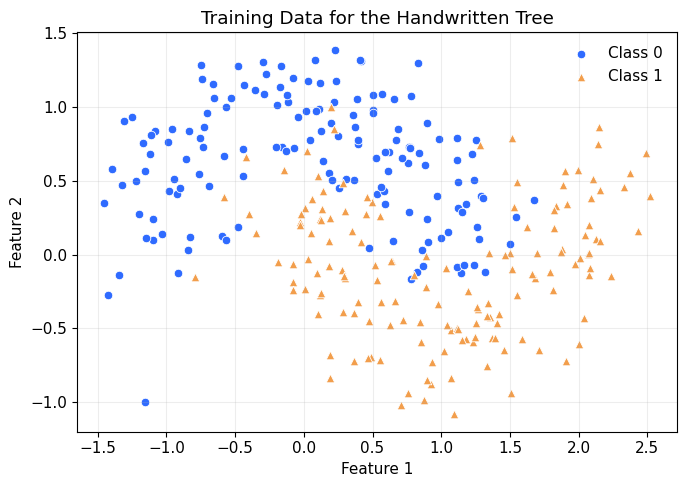

Training samples: 300; test samples: 100


In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

manual_X, manual_y = make_moons(
    n_samples=400,
    noise=0.28,
    random_state=42,
)
manual_X_train, manual_X_test, manual_y_train, manual_y_test = train_test_split(
    manual_X,
    manual_y,
    test_size=0.25,
    random_state=42,
    stratify=manual_y,
)

fig, ax = plt.subplots(figsize=(7, 5))
for class_value, color, marker in [(0, BLUE, "o"), (1, ORANGE, "^")]:
    mask = manual_y_train == class_value
    ax.scatter(
        manual_X_train[mask, 0],
        manual_X_train[mask, 1],
        c=color,
        marker=marker,
        s=38,
        edgecolor="white",
        linewidth=0.6,
        label=f"Class {class_value}",
    )
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Training Data for the Handwritten Tree")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Training samples: {len(manual_X_train)}; test samples: {len(manual_X_test)}")

<a id="scratch-model"></a>
### 2.3 模型实现：节点结构与递归建树

手写模型的每个节点保存：当前预测类别和概率、划分特征、阈值、左右子节点。
`_best_split` 枚举连续特征中相邻取值的中点，以最小加权基尼指数选择划分；
`_grow_tree` 在满足停止条件前递归调用自身。

这段代码刻意保留完整循环，便于把公式和程序逐行对应。实际 sklearn 使用更高效的底层实现。

In [5]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class TreeNode:
    prediction: int
    probabilities: np.ndarray
    n_samples: int
    impurity: float
    depth: int
    feature_index: Optional[int] = None
    threshold: Optional[float] = None
    left: Optional["TreeNode"] = None
    right: Optional["TreeNode"] = None

    @property
    def is_leaf(self):
        return self.left is None and self.right is None


class DecisionTreeClassifierScratch:
    '''A small CART-style binary classification tree using NumPy only.'''

    def __init__(self, max_depth=5, min_samples_leaf=5, min_impurity_decrease=1e-9):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease

    @staticmethod
    def _gini(encoded_y, n_classes):
        if len(encoded_y) == 0:
            return 0.0
        counts = np.bincount(encoded_y, minlength=n_classes)
        probabilities = counts / len(encoded_y)
        return 1.0 - np.sum(probabilities ** 2)

    def _best_split(self, X, encoded_y):
        n_samples, n_features = X.shape
        parent_impurity = self._gini(encoded_y, self.n_classes_)
        best = None
        best_decrease = 0.0

        for feature_index in range(n_features):
            unique_values = np.unique(X[:, feature_index])
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2.0

            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                n_left = int(left_mask.sum())
                n_right = n_samples - n_left
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                left_impurity = self._gini(encoded_y[left_mask], self.n_classes_)
                right_impurity = self._gini(encoded_y[~left_mask], self.n_classes_)
                weighted_impurity = (
                    n_left / n_samples * left_impurity
                    + n_right / n_samples * right_impurity
                )
                decrease = parent_impurity - weighted_impurity

                if decrease > best_decrease:
                    best_decrease = decrease
                    best = (feature_index, threshold, left_mask, decrease)

        return best

    def _grow_tree(self, X, encoded_y, depth):
        counts = np.bincount(encoded_y, minlength=self.n_classes_)
        probabilities = counts / len(encoded_y)
        prediction = int(np.argmax(counts))
        impurity = self._gini(encoded_y, self.n_classes_)
        node = TreeNode(
            prediction=prediction,
            probabilities=probabilities,
            n_samples=len(encoded_y),
            impurity=impurity,
            depth=depth,
        )

        stop = (
            depth >= self.max_depth
            or len(encoded_y) < 2 * self.min_samples_leaf
            or impurity == 0.0
        )
        if stop:
            return node

        split = self._best_split(X, encoded_y)
        if split is None or split[3] < self.min_impurity_decrease:
            return node

        feature_index, threshold, left_mask, _ = split
        node.feature_index = feature_index
        node.threshold = float(threshold)
        node.left = self._grow_tree(X[left_mask], encoded_y[left_mask], depth + 1)
        node.right = self._grow_tree(X[~left_mask], encoded_y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        if X.ndim != 2 or len(X) != len(y) or len(X) == 0:
            raise ValueError("X and y must contain the same non-zero number of samples")
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        encoded_y = np.searchsorted(self.classes_, y)
        self.root_ = self._grow_tree(X, encoded_y, depth=0)
        return self

    def _leaf_for_sample(self, sample):
        node = self.root_
        while not node.is_leaf:
            if sample[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return np.vstack([self._leaf_for_sample(sample).probabilities for sample in X])

    def predict(self, X):
        encoded_predictions = np.argmax(self.predict_proba(X), axis=1)
        return self.classes_[encoded_predictions]

<a id="scratch-evaluation"></a>
### 2.4 训练评估：决策边界与分类指标

训练使用基尼下降量寻找划分；评估则在测试集上比较最终类别。
训练准则和评估指标承担不同职责：基尼指数用于**长树**，Accuracy、Precision、Recall、F1
用于**检查树对未见样本的预测结果**。

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

manual_model = DecisionTreeClassifierScratch(
    max_depth=5,
    min_samples_leaf=5,
).fit(manual_X_train, manual_y_train)

manual_probability = manual_model.predict_proba(manual_X_test)
manual_prediction = manual_model.predict(manual_X_test)
manual_metrics = {
    "Accuracy": accuracy_score(manual_y_test, manual_prediction),
    "Precision": precision_score(manual_y_test, manual_prediction),
    "Recall": recall_score(manual_y_test, manual_prediction),
    "F1": f1_score(manual_y_test, manual_prediction),
}
manual_confusion = confusion_matrix(manual_y_test, manual_prediction)

for metric_name, metric_value in manual_metrics.items():
    print(f"{metric_name:9s}: {metric_value:.4f}")
print("Confusion matrix:\n", manual_confusion)

Accuracy : 0.9200
Precision: 0.9375
Recall   : 0.9000
F1       : 0.9184
Confusion matrix:
 [[47  3]
 [ 5 45]]


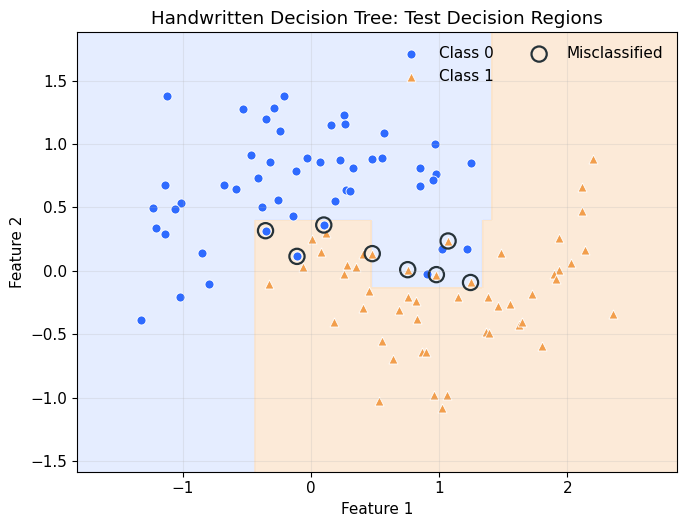

In [7]:
def plot_decision_regions(
    model,
    X,
    y,
    title,
    predictions=None,
    class_names=None,
    x_label="Feature 1",
    y_label="Feature 2",
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 320),
        np.linspace(y_min, y_max, 320),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_prediction = model.predict(grid).reshape(xx.shape)
    class_values = np.unique(y)
    region_colors = ListedColormap(["#DDE7FF", "#FBE4CC", "#E6E9D8"][:len(class_values)])
    point_colors = [BLUE, ORANGE, OLIVE]
    markers = ["o", "^", "s"]

    fig, ax = plt.subplots(figsize=(7, 5.4))
    ax.contourf(xx, yy, grid_prediction, alpha=0.75, cmap=region_colors)
    for position, class_value in enumerate(class_values):
        mask = y == class_value
        label = class_names[position] if class_names is not None else f"Class {class_value}"
        ax.scatter(
            X[mask, 0], X[mask, 1],
            c=point_colors[position], marker=markers[position],
            s=42, edgecolor="white", linewidth=0.6, label=label,
        )
    if predictions is not None:
        incorrect = predictions != y
        if incorrect.any():
            ax.scatter(
                X[incorrect, 0], X[incorrect, 1],
                facecolors="none", edgecolors=DARK, marker="o",
                s=120, linewidth=1.6, label="Misclassified",
            )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

plot_decision_regions(
    manual_model,
    manual_X_test,
    manual_y_test,
    "Handwritten Decision Tree: Test Decision Regions",
    predictions=manual_prediction,
)

<a id="depth-experiment"></a>
### 2.5 复杂度控制：树深度与过拟合

浅树只能形成少量矩形区域，可能欠拟合；深树可以形成更细碎的区域，训练准确率通常继续提高，
但测试准确率不一定同步提高。下面只改变 `max_depth`，观察同一个手写模型的训练/测试表现。

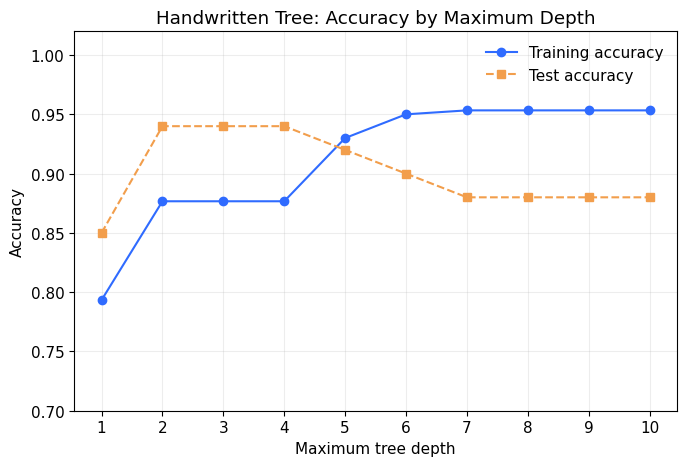

In [8]:
depths = np.arange(1, 11)
depth_train_accuracy = []
depth_test_accuracy = []

for depth in depths:
    depth_model = DecisionTreeClassifierScratch(
        max_depth=int(depth),
        min_samples_leaf=3,
    ).fit(manual_X_train, manual_y_train)
    depth_train_accuracy.append(
        accuracy_score(manual_y_train, depth_model.predict(manual_X_train))
    )
    depth_test_accuracy.append(
        accuracy_score(manual_y_test, depth_model.predict(manual_X_test))
    )

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(depths, depth_train_accuracy, "o-", color=BLUE, label="Training accuracy")
ax.plot(depths, depth_test_accuracy, "s--", color=ORANGE, label="Test accuracy")
ax.set_xlabel("Maximum tree depth")
ax.set_ylabel("Accuracy")
ax.set_title("Handwritten Tree: Accuracy by Maximum Depth")
ax.set_xticks(depths)
ax.set_ylim(0.70, 1.02)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<a id="sklearn"></a>
## 3. sklearn 调用与案例

<a id="sklearn-basic"></a>
### 3.1 分类调用：Iris 决策边界与树结构

先使用 Iris 的花瓣长度和花瓣宽度预测三个鸢尾花类别。这里只选两个特征，是为了画二维边界；
决策树不依赖距离或梯度，因此通常**不需要标准化特征**。

Accuracy        : 0.9737
Macro Precision : 0.9762
Macro Recall    : 0.9744
Macro F1        : 0.9743


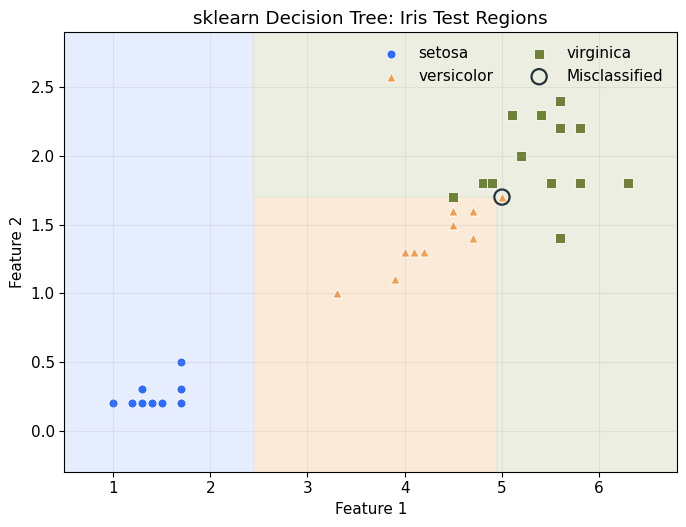

In [9]:
from IPython.display import HTML, display
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))

iris = load_iris()
iris_X = iris.data[:, [2, 3]]
iris_y = iris.target
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X,
    iris_y,
    test_size=0.25,
    random_state=42,
    stratify=iris_y,
)

iris_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=3,
    random_state=42,
).fit(iris_X_train, iris_y_train)
iris_prediction = iris_model.predict(iris_X_test)
iris_metrics = {
    "Accuracy": accuracy_score(iris_y_test, iris_prediction),
    "Macro Precision": precision_score(
        iris_y_test, iris_prediction, average="macro", zero_division=0
    ),
    "Macro Recall": recall_score(
        iris_y_test, iris_prediction, average="macro", zero_division=0
    ),
    "Macro F1": f1_score(
        iris_y_test, iris_prediction, average="macro", zero_division=0
    ),
}
for metric_name, metric_value in iris_metrics.items():
    print(f"{metric_name:16s}: {metric_value:.4f}")

plot_decision_regions(
    iris_model,
    iris_X_test,
    iris_y_test,
    "sklearn Decision Tree: Iris Test Regions",
    predictions=iris_prediction,
    class_names=iris.target_names,
)

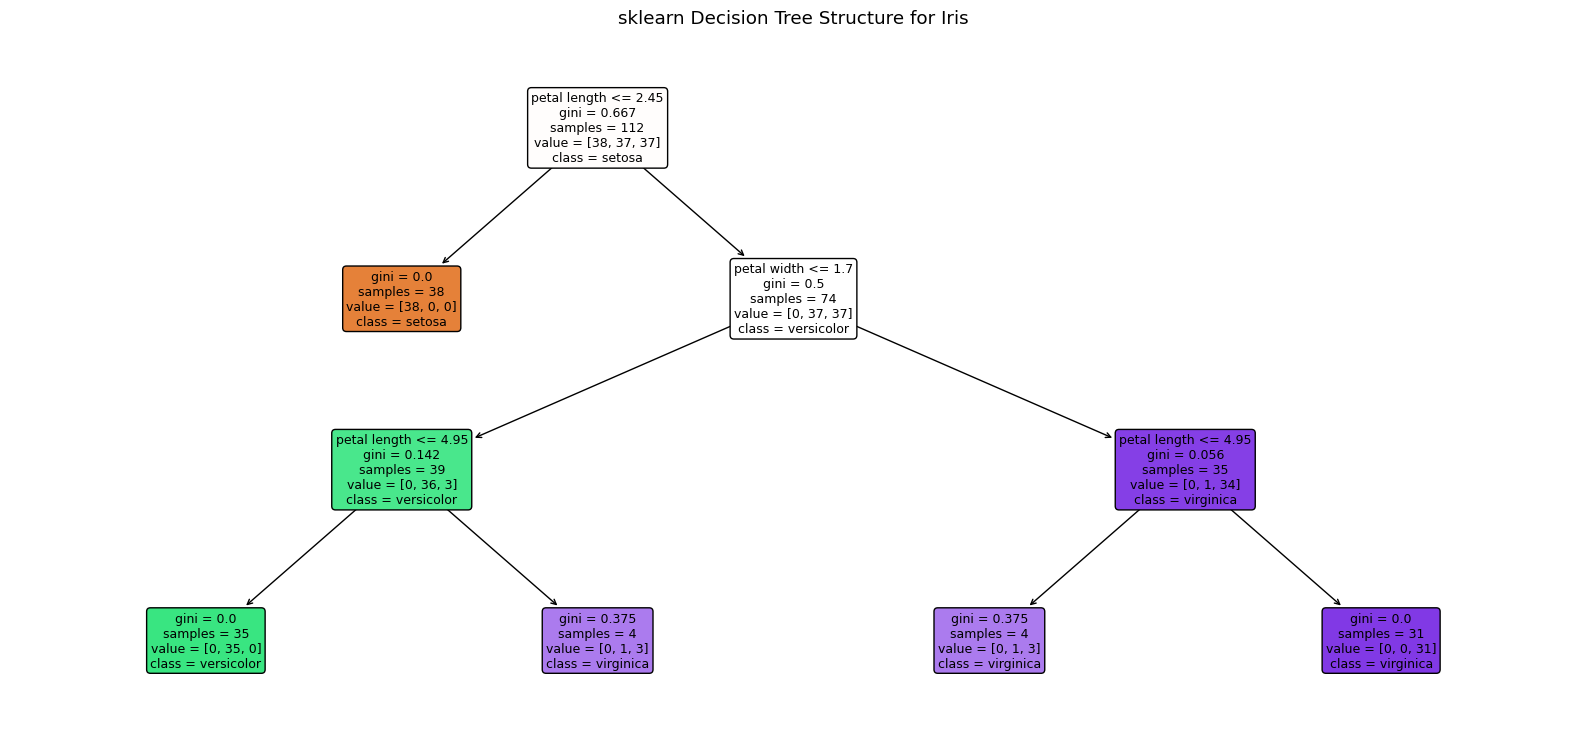

In [10]:
fig, ax = plt.subplots(figsize=(16, 7.5))
plot_tree(
    iris_model,
    feature_names=["petal length", "petal width"],
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9,
    ax=ax,
)
ax.set_title("sklearn Decision Tree Structure for Iris", pad=14)
plt.tight_layout()
plt.show()

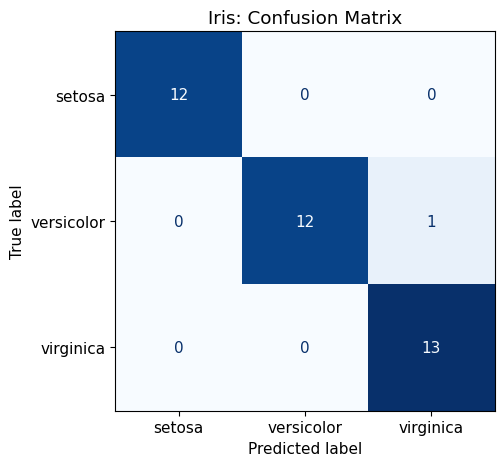

In [11]:
ConfusionMatrixDisplay.from_predictions(
    iris_y_test,
    iris_prediction,
    display_labels=iris.target_names,
    cmap="Blues",
    colorbar=False,
)
plt.title("Iris: Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

决策边界展示二维特征空间中的分类区域，树结构展示规则来源，
混淆矩阵则说明每个 Iris 类别具体被分到了哪里。

<a id="real-case"></a>
### 3.2 分类案例：乳腺癌良恶性诊断

`load_breast_cancer` 包含 569 个样本、30 个由细胞核图像提取的数值特征。
标签 0 表示 malignant（恶性），标签 1 表示 benign（良性）。为了与上一章逻辑回归比较，
这里使用同一数据集；本节将恶性类别 0 视为评估中的正类。

`max_depth=4` 和 `min_samples_leaf=5` 是直观的预剪枝设置，用来限制树的复杂度。

正式模型使用全部 30 个特征，其真实边界无法直接投到二维平面。后面额外训练一个
**PCA 二维投影模型**绘制边界，仅用于理解树如何分区；混淆矩阵和 ROC 仍来自完整模型。
因此它应读作：**PCA 二维投影边界（仅用于可视化）**。

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, roc_curve

cancer = load_breast_cancer()
cancer_X_train, cancer_X_test, cancer_y_train, cancer_y_test = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.20,
    random_state=42,
    stratify=cancer.target,
)

cancer_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
).fit(cancer_X_train, cancer_y_train)
cancer_prediction = cancer_model.predict(cancer_X_test)
malignant_column = list(cancer_model.classes_).index(0)
cancer_probability_malignant = cancer_model.predict_proba(cancer_X_test)[:, malignant_column]
cancer_roc_auc = roc_auc_score(
    (cancer_y_test == 0).astype(int),
    cancer_probability_malignant,
)

cancer_metrics = {
    "Accuracy": accuracy_score(cancer_y_test, cancer_prediction),
    "Precision (malignant)": precision_score(cancer_y_test, cancer_prediction, pos_label=0),
    "Recall (malignant)": recall_score(cancer_y_test, cancer_prediction, pos_label=0),
    "F1 (malignant)": f1_score(cancer_y_test, cancer_prediction, pos_label=0),
    "ROC-AUC (malignant)": cancer_roc_auc,
}
for metric_name, metric_value in cancer_metrics.items():
    print(f"{metric_name:21s}: {metric_value:.4f}")
print(f"Tree depth: {cancer_model.get_depth()}; leaves: {cancer_model.get_n_leaves()}")

display_result_table(
    "乳腺癌决策树真实案例指标表",
    ["指标", "数值", "含义"],
    [
        ["Accuracy", f'{cancer_metrics["Accuracy"]:.3f}', "总体预测正确率"],
        ["Precision", f'{cancer_metrics["Precision (malignant)"]:.3f}', "预测恶性时的准确程度"],
        ["Recall", f'{cancer_metrics["Recall (malignant)"]:.3f}', "恶性样本被识别的比例"],
        ["F1", f'{cancer_metrics["F1 (malignant)"]:.3f}', "Precision 与 Recall 的调和平均"],
        ["ROC-AUC", f'{cancer_roc_auc:.3f}', "全部阈值下识别恶性的排序能力"],
    ],
)

Accuracy             : 0.9211
Precision (malignant): 0.8837
Recall (malignant)   : 0.9048
F1 (malignant)       : 0.8941
ROC-AUC (malignant)  : 0.9263
Tree depth: 4; leaves: 10


指标,数值,含义
Accuracy,0.921,总体预测正确率
Precision,0.884,预测恶性时的准确程度
Recall,0.905,恶性样本被识别的比例
F1,0.894,Precision 与 Recall 的调和平均
ROC-AUC,0.926,全部阈值下识别恶性的排序能力


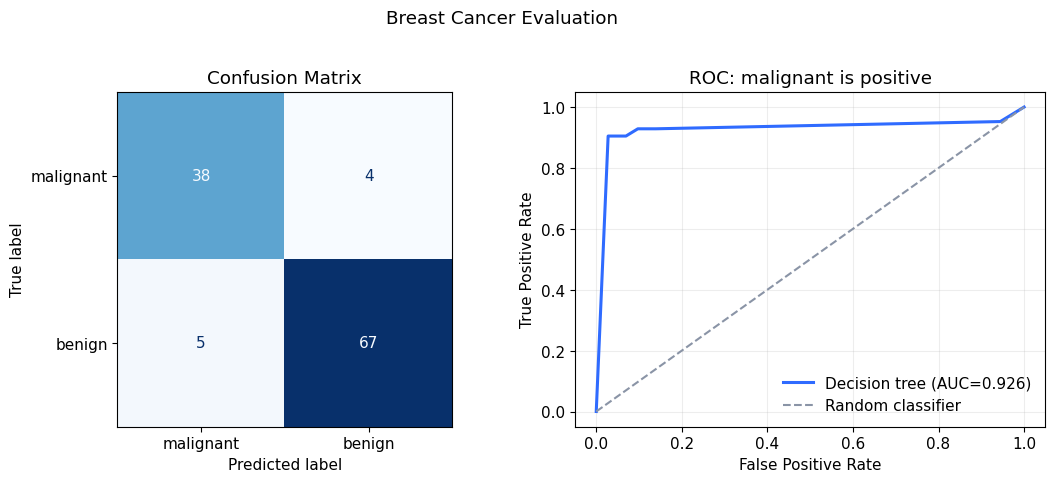

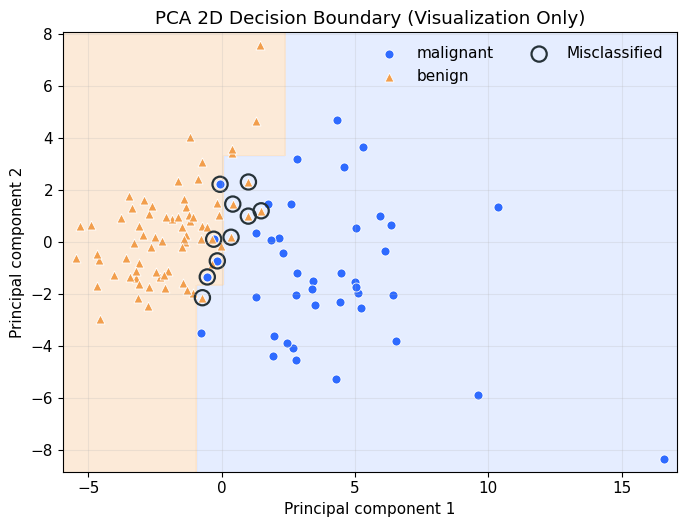

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
ConfusionMatrixDisplay.from_predictions(
    cancer_y_test,
    cancer_prediction,
    display_labels=cancer.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")
axes[0].grid(False)

false_positive_rate, true_positive_rate, _ = roc_curve(
    cancer_y_test,
    cancer_probability_malignant,
    pos_label=0,
)
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    color=BLUE,
    linewidth=2.2,
    label=f"Decision tree (AUC={cancer_roc_auc:.3f})",
)
axes[1].plot([0, 1], [0, 1], "--", color=GREY, label="Random classifier")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC: malignant is positive")
axes[1].legend(frameon=False, loc="lower right")
fig.suptitle("Breast Cancer Evaluation", y=1.02)
plt.tight_layout()
plt.show()

cancer_visual_scaler = StandardScaler()
cancer_X_train_scaled = cancer_visual_scaler.fit_transform(cancer_X_train)
cancer_X_test_scaled = cancer_visual_scaler.transform(cancer_X_test)
cancer_visual_pca = PCA(n_components=2, random_state=42)
cancer_X_train_pca = cancer_visual_pca.fit_transform(cancer_X_train_scaled)
cancer_X_test_pca = cancer_visual_pca.transform(cancer_X_test_scaled)
cancer_visual_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42,
).fit(cancer_X_train_pca, cancer_y_train)
cancer_visual_prediction = cancer_visual_model.predict(cancer_X_test_pca)
plot_decision_regions(
    cancer_visual_model,
    cancer_X_test_pca,
    cancer_y_test,
    "PCA 2D Decision Boundary (Visualization Only)",
    predictions=cancer_visual_prediction,
    class_names=cancer.target_names,
    x_label="Principal component 1",
    y_label="Principal component 2",
)

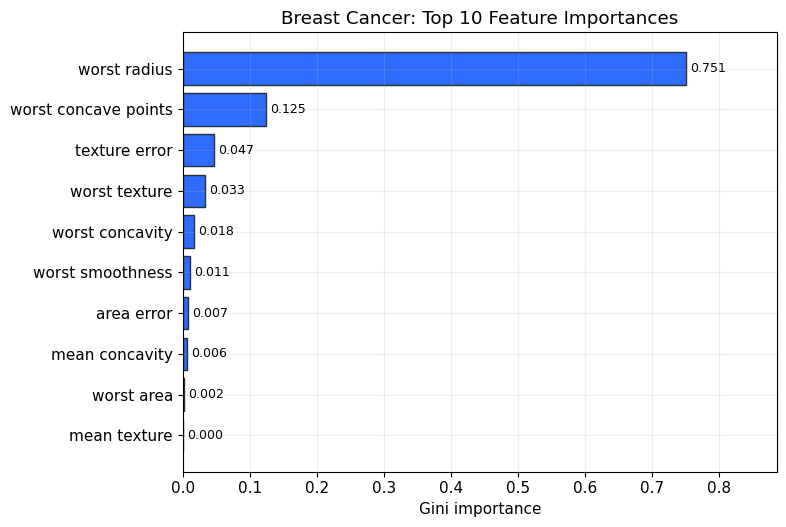

In [14]:
importance_order = np.argsort(cancer_model.feature_importances_)[-10:]
importance_values = cancer_model.feature_importances_[importance_order]
importance_names = cancer.feature_names[importance_order]

fig, ax = plt.subplots(figsize=(8, 5.4))
bars = ax.barh(
    importance_names,
    importance_values,
    color=BLUE,
    edgecolor=DARK,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("Gini importance")
ax.set_title("Breast Cancer: Top 10 Feature Importances")
ax.set_xlim(0, max(importance_values) * 1.18)
plt.tight_layout()
plt.show()

<a id="regression-case"></a>
### 3.3 回归案例：糖尿病进展预测

原理部分已经推导了回归树的平方误差与叶节点均值。这里直接使用糖尿病数据，
用 `DecisionTreeRegressor` 预测连续的疾病进展指标，并报告 MAE、RMSE 与 (R^2)。

MAE : 44.378
MSE : 3072.536
RMSE: 55.430
R^2 : 0.420


指标,数值,含义
MAE,44.378,平均绝对预测误差
MSE,3072.536,平方误差的平均值
RMSE,55.430,与目标同量纲，对大误差更敏感
R²,0.420,相对恒预测均值基线解释的变异


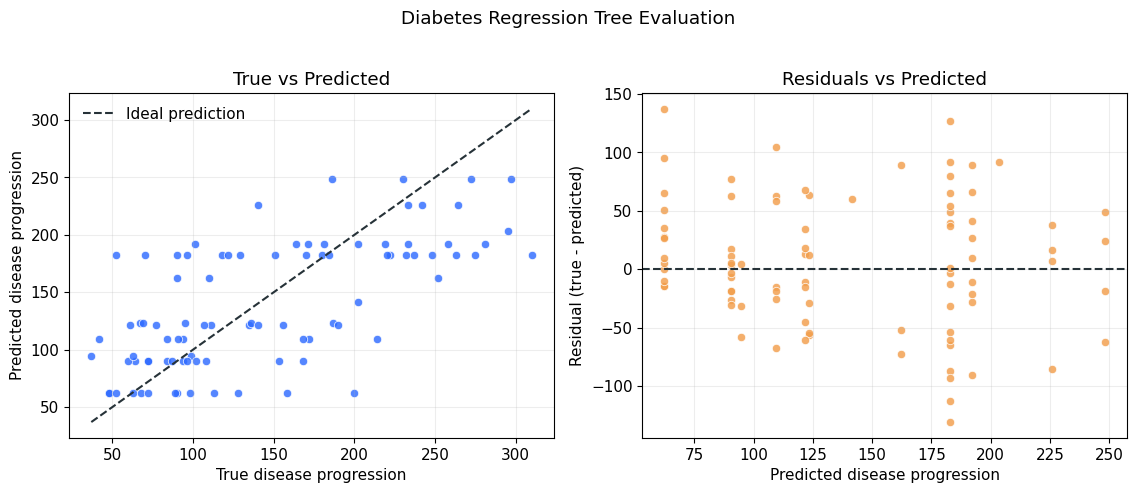

In [15]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

diabetes = load_diabetes()
regression_X_train, regression_X_test, regression_y_train, regression_y_test = train_test_split(
    diabetes.data,
    diabetes.target,
    test_size=0.20,
    random_state=42,
)

regression_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=8,
    random_state=42,
).fit(regression_X_train, regression_y_train)
regression_prediction = regression_model.predict(regression_X_test)

regression_mae = mean_absolute_error(regression_y_test, regression_prediction)
regression_mse = mean_squared_error(
    regression_y_test,
    regression_prediction,
)
regression_rmse = np.sqrt(regression_mse)
regression_r2 = r2_score(regression_y_test, regression_prediction)
regression_residuals = regression_y_test - regression_prediction
print(f"MAE : {regression_mae:.3f}")
print(f"MSE : {regression_mse:.3f}")
print(f"RMSE: {regression_rmse:.3f}")
print(f"R^2 : {regression_r2:.3f}")

display_result_table(
    "糖尿病决策树回归指标表",
    ["指标", "数值", "含义"],
    [
        ["MAE", f"{regression_mae:.3f}", "平均绝对预测误差"],
        ["MSE", f"{regression_mse:.3f}", "平方误差的平均值"],
        ["RMSE", f"{regression_rmse:.3f}", "与目标同量纲，对大误差更敏感"],
        ["R²", f"{regression_r2:.3f}", "相对恒预测均值基线解释的变异"],
    ],
)

value_min = min(regression_y_test.min(), regression_prediction.min())
value_max = max(regression_y_test.max(), regression_prediction.max())
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
axes[0].scatter(
    regression_y_test,
    regression_prediction,
    c=BLUE,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.82,
)
axes[0].plot(
    [value_min, value_max],
    [value_min, value_max],
    "--",
    color=DARK,
    label="Ideal prediction",
)
axes[0].set(
    xlabel="True disease progression",
    ylabel="Predicted disease progression",
    title="True vs Predicted",
)
axes[0].legend(frameon=False)

axes[1].scatter(
    regression_prediction,
    regression_residuals,
    c=ORANGE,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.82,
)
axes[1].axhline(0, color=DARK, linestyle="--", linewidth=1.5)
axes[1].set(
    xlabel="Predicted disease progression",
    ylabel="Residual (true - predicted)",
    title="Residuals vs Predicted",
)
fig.suptitle("Diabetes Regression Tree Evaluation", y=1.02)
plt.tight_layout()
plt.show()

左图越接近对角线，预测越准确；右图的残差若能在 0 附近随机分布，
说明模型没有明显的系统性高估或低估。这里残差仍较分散，符合单棵浅树拟合能力有限的结果。

<a id="summary"></a>
## 4. 章节小结

- 决策树通过递归划分特征空间完成预测；核心是让子节点比父节点更纯。
- 信息增益和基尼下降量都是“划分带来多少纯度提升”的度量。
- 分类树的叶节点输出多数类别及类别频率；回归树的叶节点通常输出目标均值。
- 深树训练误差低，但容易过拟合；`max_depth`、`min_samples_leaf` 和剪枝用于控制复杂度。
- 决策树通常不需要标准化，并且能直接给出规则、树结构和特征重要性。
- 单棵树可能不稳定；后续的随机森林和梯度提升树会通过组合多棵树改善泛化能力。

In [16]:
probability_row_sum_error = float(
    np.max(np.abs(manual_probability.sum(axis=1) - 1.0))
)
regression_values = np.array([
    regression_mae,
    regression_mse,
    regression_rmse,
    regression_r2,
])
validation = {
    "manual_accuracy": float(manual_metrics["Accuracy"]),
    "probability_min": float(manual_probability.min()),
    "probability_max": float(manual_probability.max()),
    "probability_row_sum_error": probability_row_sum_error,
    "iris_accuracy": float(iris_metrics["Accuracy"]),
    "cancer_accuracy": float(cancer_metrics["Accuracy"]),
    "cancer_roc_auc": float(cancer_roc_auc),
    "regression_mae": float(regression_mae),
    "regression_mse": float(regression_mse),
    "regression_rmse": float(regression_rmse),
    "regression_r2": float(regression_r2),
    "regression_metrics_finite": bool(np.all(np.isfinite(regression_values))),
    "image_count": 13,
}

assert 0.0 <= manual_probability.min() <= manual_probability.max() <= 1.0
assert probability_row_sum_error < 1e-12
assert manual_metrics["Accuracy"] >= 0.75
assert iris_metrics["Accuracy"] >= 0.85
assert cancer_metrics["Accuracy"] >= 0.85
assert 0.85 <= cancer_roc_auc <= 1.0
assert np.all(np.isfinite(regression_values))

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写树 Accuracy", f'{validation["manual_accuracy"]:.3f}', "通过"],
        ["Iris Accuracy", f'{validation["iris_accuracy"]:.3f}', "通过"],
        ["乳腺癌 Accuracy", f'{validation["cancer_accuracy"]:.3f}', "通过"],
        ["乳腺癌 ROC-AUC", f'{validation["cancer_roc_auc"]:.3f}', "通过"],
        ["糖尿病回归 R²", f'{validation["regression_r2"]:.3f}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写树 Accuracy,0.920,通过
Iris Accuracy,0.974,通过
乳腺癌 Accuracy,0.921,通过
乳腺癌 ROC-AUC,0.926,通过
糖尿病回归 R²,0.420,通过
已执行图表输出,13,通过
